In [1]:
import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, when, isnan, isnull, mean, stddev, skewness, kurtosis,
    min as spark_min, max as spark_max, expr, countDistinct
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
spark = SparkSession.builder \
    .appName("BigDataProject_EDA") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.python.worker.reuse", "false") \
    .getOrCreate()

In [4]:
full_df = spark.read.option("header", "true").option("inferSchema", "true").csv("combined_dataset")
full_df = full_df.cache()
print("Rows:", full_df.count())

Rows: 128621


In [5]:
# One Spark job computing everything, then pure Python for the rest — no further Spark actions needed
stats_row = full_df.select(
    [count(when(col(c).isNull(), c)).alias(f"null_{c}") for c in full_df.columns] +
    [countDistinct(col(c)).alias(f"distinct_{c}") for c in full_df.columns]
).collect()[0]

total_rows = full_df.count()

print(f"{'Column':<25}{'Nulls':<10}{'Null %':<10}{'Distinct':<10}")
for c in full_df.columns:
    null_count = stats_row[f"null_{c}"]
    distinct_count = stats_row[f"distinct_{c}"]
    null_pct = round((null_count / total_rows) * 100, 2)
    print(f"{c:<25}{null_count:<10}{null_pct:<10}{distinct_count:<10}")

Column                   Nulls     Null %    Distinct  
operator_ref             0         0.0       8         
route_number             0         0.0       201       
pulled_at                0         0.0       192       
recorded_at              0         0.0       3360      
vehicle_ref              0         0.0       665       
latitude                 0         0.0       49686     
longitude                0         0.0       53463     
bearing                  47631     37.03     360       
avl_id                   0         0.0       128621    
avl_time_of_day          0         0.0       3360      
source_file              101392    78.83     61        
service_ref              101392    78.83     30        
line_ref                 101392    78.83     34        
journey_code             101392    78.83     109       
departure_time           101392    78.83     64        
days_of_week             101392    78.83     3         
stop_count               101392    78.83     45 

In [6]:
numeric_cols = ["latitude", "longitude", "bearing", "avg_fare_gbp", "disruption_count"]

full_df.select(numeric_cols).describe().show()

for c in numeric_cols:
    median_val = full_df.approxQuantile(c, [0.5], 0.01)
    print(f"{c} median: {median_val[0]}")

+-------+------------------+-------------------+------------------+-------------------+------------------+
|summary|          latitude|          longitude|           bearing|       avg_fare_gbp|  disruption_count|
+-------+------------------+-------------------+------------------+-------------------+------------------+
|  count|            128621|             128621|             80990|             127469|            128621|
|   mean| 50.92130809525618|-1.6630272677090074|180.18691196444004| 3.0891856843877874|11.575372606339556|
| stddev|0.2664456784813009|0.27529250460199256|103.19973756850426|0.35513736350585745|3.4971327419209386|
|    min|          50.59454|          -2.470852|                 0|  1.630769230769231|                 3|
|    max|         51.609716|          -1.078085|               359|  3.508187134502923|                23|
+-------+------------------+-------------------+------------------+-------------------+------------------+

latitude median: 50.861011
longitude

In [7]:
skew_kurt_row = full_df.select(
    [skewness(c).alias(f"{c}_skewness") for c in numeric_cols] +
    [kurtosis(c).alias(f"{c}_kurtosis") for c in numeric_cols]
).collect()[0]

print(f"{'Column':<20}{'Skewness':<15}{'Kurtosis':<15}")
for c in numeric_cols:
    print(f"{c:<20}{skew_kurt_row[f'{c}_skewness']:<15.3f}{skew_kurt_row[f'{c}_kurtosis']:<15.3f}")

Column              Skewness       Kurtosis       
latitude            1.389          0.927          
longitude           0.028          -0.828         
bearing             0.004          -1.196         
avg_fare_gbp        -2.802         9.706          
disruption_count    0.119          -0.226         


In [8]:
def detect_outliers_iqr(df, column):
    quantiles = df.approxQuantile(column, [0.25, 0.75], 0.01)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = df.filter((col(column) < lower_bound) | (col(column) > upper_bound)).count()
    print(f"{column}: Q1={q1:.2f}, Q3={q3:.2f}, bounds=({lower_bound:.2f}, {upper_bound:.2f}), outliers={outlier_count}")

for c in numeric_cols:
    detect_outliers_iqr(full_df, c)

latitude: Q1=50.72, Q3=50.97, bounds=(50.36, 51.34), outliers=15880
longitude: Q1=-1.87, Q3=-1.40, bounds=(-2.58, -0.70), outliers=0
bearing: Q1=92.00, Q3=269.00, bounds=(-173.50, 534.50), outliers=0
avg_fare_gbp: Q1=2.94, Q3=3.19, bounds=(2.57, 3.56), outliers=5568
disruption_count: Q1=9.00, Q3=14.00, bounds=(1.50, 21.50), outliers=382


In [9]:
distinct_rows = full_df.distinct().count()
duplicate_rows = total_rows - distinct_rows
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [10]:
distinct_rows = full_df.distinct().count()
duplicate_rows = total_rows - distinct_rows
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


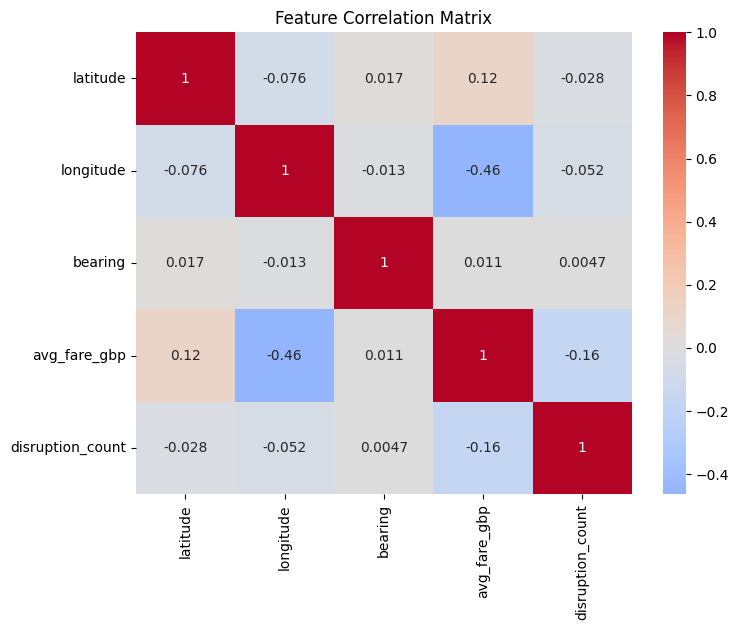

In [11]:
corr_pandas = full_df.select(numeric_cols).toPandas()
corr_matrix = corr_pandas.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.show()

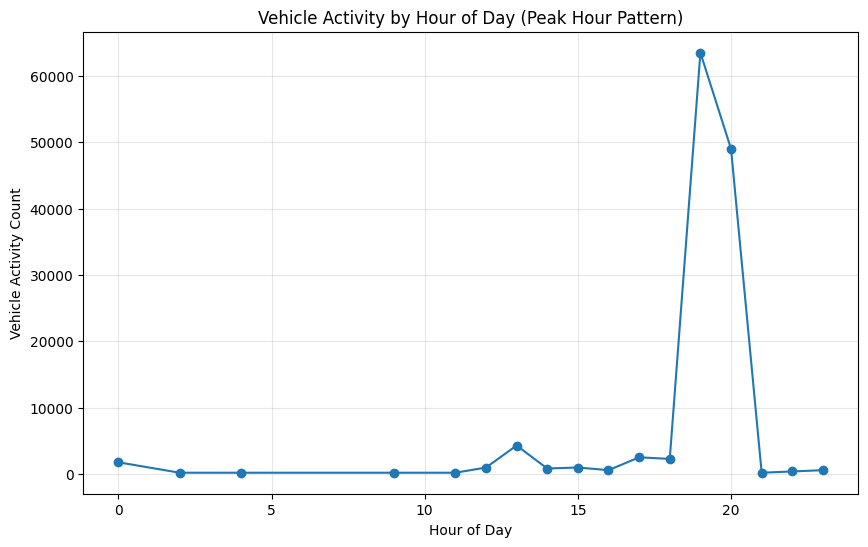

In [12]:
from pyspark.sql.functions import hour

hourly_pandas = full_df.groupBy(hour("recorded_at").alias("hour_of_day")).count().orderBy("hour_of_day").toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(hourly_pandas["hour_of_day"], hourly_pandas["count"], marker="o")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Vehicle Activity Count")
ax.set_title("Vehicle Activity by Hour of Day (Peak Hour Pattern)")
ax.grid(True, alpha=0.3)
plt.show()